In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("transaction data.csv")

In [13]:
df.head()

,transaction_id,date,customer_name,category,amount,status
0,T001,1/15/2026,John Smith,Electronics,299.99,Completed
1,T002,1/16/2026,alice jones,groceries,45.50,completed
2,T003,1/17/2026,BOB BROWN,Electronics,NaN,Pending
3,T004,1/18/2026,Charlie Davis,Clothing,120.00,Failed
4,T002,1/16/2026,alice jones,groceries,45.50,completed


In [14]:
df.shape

(9, 6)

In [15]:
df.dtypes

transaction_id     object
date               object
customer_name      object
category           object
amount            float64
status             object
dtype: object

In [12]:
df.describe()

,amount
count,8.000000
mean,110.383750
std,126.874816
min,-50.000000
25%,42.150000
50%,67.745000
75%,164.997500
max,299.990000


In [17]:
# ---- STEP 1: Clean the data ----

# 1a. Strip whitespace from string columns
df['customer_name'] = df['customer_name'].str.strip()
df['category'] = df['category'].str.strip()
df['status'] = df['status'].str.strip()

# 1b. Standardize casing
df['customer_name'] = df['customer_name'].str.title()
df['category'] = df['category'].str.title()
df['status'] = df['status'].str.title()

# 1c. Convert date to proper datetime type
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# 1d. Check what we have after cleaning
print("After cleaning:")
print(df.head(10))
print("\nData types now:")
print(df.dtypes)

After cleaning:
  transaction_id       date  customer_name     category  amount     status
0           T001 2026-01-15     John Smith  Electronics  299.99  Completed
1           T002 2026-01-16    Alice Jones    Groceries   45.50  Completed
2           T003 2026-01-17      Bob Brown  Electronics     NaN    Pending
3           T004 2026-01-18  Charlie Davis     Clothing  120.00     Failed
4           T002 2026-01-16    Alice Jones    Groceries   45.50  Completed
5           T005        NaT      Eva Green    Groceries   32.10  Completed
6           T006 2026-01-20    Frank White         Home   89.99  Completed
7           T007 2026-01-21     Grace Hall     Clothing  -50.00   Refunded
8           T008 2026-01-22     John Smith  Electronics  299.99  Completed

Data types now:
transaction_id            object
date              datetime64[ns]
customer_name             object
category                  object
amount                   float64
status                    object
dtype: object


In [18]:
# ---- STEP 2: Flag Anomalies ----

# 2a. Calculate statistical threshold
mean_amount = df['amount'].mean()
std_amount = df['amount'].std()
threshold = mean_amount + (2 * std_amount)

print(f"Mean: {mean_amount:.2f}")
print(f"Std Dev: {std_amount:.2f}")
print(f"Anomaly Threshold (mean + 2*std): {threshold:.2f}")

# 2b. Flag high-value anomalies
df['flag_high_amount'] = df['amount'] > threshold

# 2c. Flag negative amounts
df['flag_negative'] = df['amount'] < 0

# 2d. Flag missing fields
df['flag_missing_amount'] = df['amount'].isna()
df['flag_missing_date'] = df['date'].isna()

# 2e. Flag duplicate transaction IDs
df['flag_duplicate_id'] = df.duplicated(subset='transaction_id', keep=False)

# 2f. Create one combined flag — True if ANY flag is raised
df['any_flag'] = (
    df['flag_high_amount'] |
    df['flag_negative'] |
    df['flag_missing_amount'] |
    df['flag_missing_date'] |
    df['flag_duplicate_id']
)

# 2g. Show only flagged rows
flagged = df[df['any_flag'] == True]
print(f"\nTotal transactions: {len(df)}")
print(f"Flagged transactions: {len(flagged)}")
print("\nFlagged rows:")
print(flagged[['transaction_id', 'amount', 'status', 
               'flag_high_amount', 'flag_negative',
               'flag_missing_amount', 'flag_missing_date',
               'flag_duplicate_id']])

Mean: 110.38
Std Dev: 126.87
Anomaly Threshold (mean + 2*std): 364.13

Total transactions: 9
Flagged transactions: 5

Flagged rows:
  transaction_id  amount     status  flag_high_amount  flag_negative  \
1           T002    45.5  Completed             False          False   
2           T003     NaN    Pending             False          False   
4           T002    45.5  Completed             False          False   
5           T005    32.1  Completed             False          False   
7           T007   -50.0   Refunded             False           True   

   flag_missing_amount  flag_missing_date  flag_duplicate_id  
1                False              False               True  
2                 True              False              False  
4                False              False               True  
5                False               True              False  
7                False              False              False  


       TRANSACTION ANOMALY REPORT
Total Transactions Reviewed:  9
Clean Transactions:           4
Flagged Transactions:         5
Flag Rate:                    55.6%

Breakdown by Flag Type:
  High Amount (>$364):   0
  Negative Amount:              1
  Missing Amount:               1
  Missing Date:                 1
  Duplicate ID:                 2


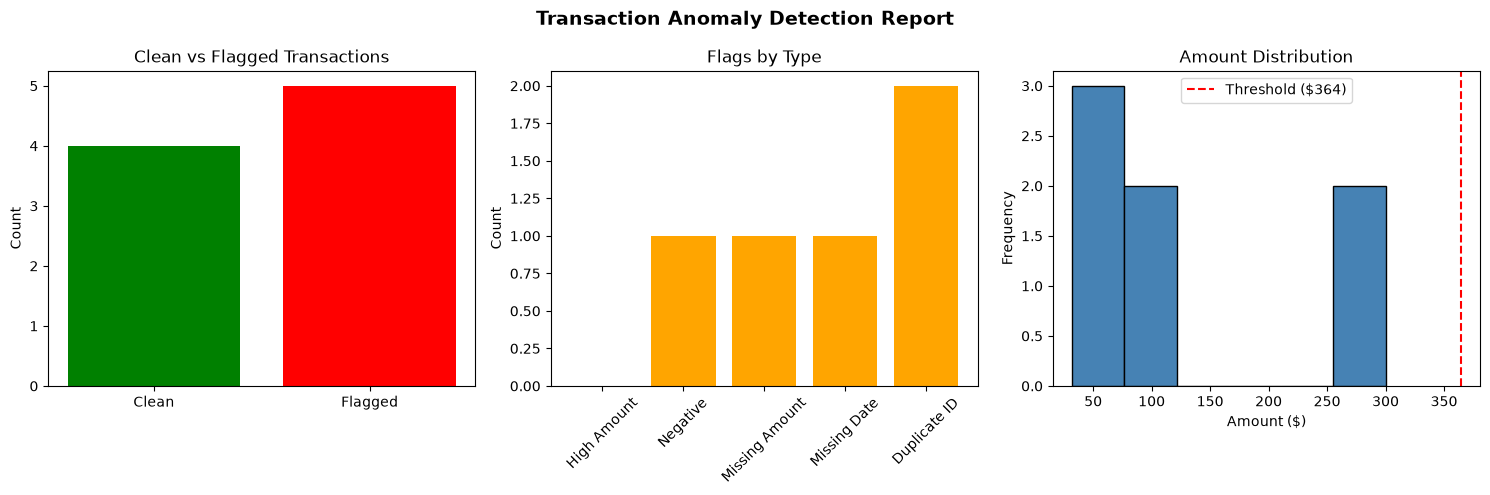

In [19]:
# ---- STEP 3: Summary Report ----

print("=" * 45)
print("       TRANSACTION ANOMALY REPORT")
print("=" * 45)
print(f"Total Transactions Reviewed:  {len(df)}")
print(f"Clean Transactions:           {len(df) - len(flagged)}")
print(f"Flagged Transactions:         {len(flagged)}")
print(f"Flag Rate:                    {len(flagged)/len(df)*100:.1f}%")
print()
print("Breakdown by Flag Type:")
print(f"  High Amount (>${threshold:.0f}):   {df['flag_high_amount'].sum()}")
print(f"  Negative Amount:              {df['flag_negative'].sum()}")
print(f"  Missing Amount:               {df['flag_missing_amount'].sum()}")
print(f"  Missing Date:                 {df['flag_missing_date'].sum()}")
print(f"  Duplicate ID:                 {df['flag_duplicate_id'].sum()}")
print("=" * 45)

# ---- STEP 4: Visualizations ----

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Transaction Anomaly Detection Report', 
             fontsize=14, fontweight='bold')

# Chart 1 — Clean vs Flagged
axes[0].bar(['Clean', 'Flagged'], 
            [len(df) - len(flagged), len(flagged)],
            color=['green', 'red'])
axes[0].set_title('Clean vs Flagged Transactions')
axes[0].set_ylabel('Count')

# Chart 2 — Flag type breakdown
flag_counts = {
    'High Amount': df['flag_high_amount'].sum(),
    'Negative': df['flag_negative'].sum(),
    'Missing Amount': df['flag_missing_amount'].sum(),
    'Missing Date': df['flag_missing_date'].sum(),
    'Duplicate ID': df['flag_duplicate_id'].sum()
}
axes[1].bar(flag_counts.keys(), flag_counts.values(), color='orange')
axes[1].set_title('Flags by Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# Chart 3 — Amount distribution with threshold line
clean_amounts = df[df['flag_negative'] == False]['amount'].dropna()
axes[2].hist(clean_amounts, bins=6, color='steelblue', edgecolor='black')
axes[2].axvline(threshold, color='red', linestyle='--', 
                label=f'Threshold (${threshold:.0f})')
axes[2].set_title('Amount Distribution')
axes[2].set_xlabel('Amount ($)')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.tight_layout()
plt.show()